# PINNs: ODE damped oscillator

$$
\begin{cases}
    0 = \ddot{x} + 2\zeta\omega.\dot{x} + \omega^2.x \\
    x(0) = x_0 \\
    \dot{x}(0) = 0
\end{cases}
$$

Solution: (underdamped, $\zeta < 1$)



In [1]:
# imports
# torch
import torch
import torch.nn as nn
import torch.optim as optim

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

In [2]:


# Define the PINN model
class PINN(nn.Module):

    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),   # Input layer with 1 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1),    # Output layer for v(t)
        )

        # equation parameters
        self.ZETTA = 0.2
        self.W = 10

    def forward(self, t):
        return self.net(t)

    # Define the Poisson equation loss function
    def damped_oscillatior_loss(self, t):
        # alias to simplify notation
        # parameters
        ZETTA = self.ZETTA
        W = self.W
        
        # compute estimation for position
        x = self.forward(t)

        # compute derivatives of first and second order
        x_t = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True)[0]
        x_tt = torch.autograd.grad(x_t, t, grad_outputs=torch.ones_like(x_t), create_graph=True)[0]

        # residue for damped oscillator
        f = (x_tt + (2*ZETTA*W)*x_t + (W**2)*x)**2
        return torch.mean(f)
    
    def boundary_condition_loss(self, t0, x0, dx0):

        # estimation for x0
        x0_est = self.forward(t0)

        # residue for x0
        initial_conditions = (x0_est - x0)**2

        # estimation for dx0
        dx0_est = torch.autograd.grad(x0_est, t0, grad_outputs=torch.ones_like(x0_est), create_graph=True)[0]

        # residue for dx0
        initial_conditions_der = (dx0_est - dx0)**2


        return torch.mean(initial_conditions) + torch.mean(initial_conditions_der)


    def data_loss(self, x, x_est):
        return nn.MSELoss()(x, x_est)
    
# Define general NN model with same architecture as PINN
class NN(nn.Module):
    def __init__(self):
        super(NN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),   # Input layer with 1 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1),    # Output layer for v(t)
        )

    def forward(self, t):
        return self.net(t)

    def data_loss(self, x, x_est):
        return nn.MSELoss()(x, x_est)


In [3]:
# Training data
t = 2*torch.rand(100, 1)  # Randomly sampled points in [0, 2]
t.requires_grad = True

# initial conditions
t0 = torch.tensor([0.0], requires_grad=True)
x0 = torch.tensor([1.0], requires_grad=True)
dx0 = torch.tensor([0.0], requires_grad=True)

# Create PINN model
model = PINN()

optimizer = optim.Adam(params=model.parameters(), lr=1e-3)

# loss tracking
losses = []

# labeled training data
# random training data
t_sample = 1*torch.rand(100, 1)
t_sample.requires_grad = False

# convenient alias
Z = model.ZETTA
w = model.W

# data
root = torch.sqrt(torch.tensor([Z**2 - 1], dtype=torch.cfloat))
x_sample = x0*torch.exp(-w*Z*t_sample)*(torch.cosh(w*root*t_sample) + (Z/root)*torch.sinh(w*root*t_sample))
x_sample = x_sample.real # get rid of aprox. complex values
x_sample = x_sample.detach()

# Training loop
epochs = 60000
for epoch in range(epochs):
    optimizer.zero_grad()

    x_est = model(t_sample)
    
    # Compute the loss
    loss = model.damped_oscillatior_loss(t) + model.boundary_condition_loss(t0, x0, dx0) + model.data_loss(x_sample, x_est)
    
    # Backpropagation
    loss.backward()
    losses.append(torch.log(loss).item())
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item()}")


Epoch [0/60000], Loss: 642.92724609375
Epoch [1000/60000], Loss: 1.1377418041229248
Epoch [2000/60000], Loss: 1.1375677585601807
Epoch [3000/60000], Loss: 1.1373056173324585
Epoch [4000/60000], Loss: 1.1369574069976807
Epoch [5000/60000], Loss: 1.136689305305481
Epoch [6000/60000], Loss: 1.285284399986267
Epoch [7000/60000], Loss: 1.1509321928024292
Epoch [8000/60000], Loss: 1.1364436149597168
Epoch [9000/60000], Loss: 1.1362342834472656
Epoch [10000/60000], Loss: 1.1362863779067993
Epoch [11000/60000], Loss: 1.1367387771606445
Epoch [12000/60000], Loss: 1.1363023519515991
Epoch [13000/60000], Loss: 1.1364988088607788
Epoch [14000/60000], Loss: 1.2486885786056519
Epoch [15000/60000], Loss: 1.1523019075393677
Epoch [16000/60000], Loss: 1.1367298364639282
Epoch [17000/60000], Loss: 1.1391901969909668
Epoch [18000/60000], Loss: 1.1395454406738281
Epoch [19000/60000], Loss: 1.1362602710723877
Epoch [20000/60000], Loss: 1.1357486248016357
Epoch [21000/60000], Loss: 1.1357142925262451
Epoch 

In [7]:
# Create PINN nn_model
nn_model = PINN()

optimizer = optim.Adam(params=nn_model.parameters(), lr=1e-3)

# loss tracking
nn_losses = []

# labeled training data
# random training data
t_sample = 1*torch.rand(100, 1)
t_sample.requires_grad = False

# convenient alias
Z = nn_model.ZETTA
w = nn_model.W

# data
root = torch.sqrt(torch.tensor([Z**2 - 1], dtype=torch.cfloat))
x_sample = x0*torch.exp(-w*Z*t_sample)*(torch.cosh(w*root*t_sample) + (Z/root)*torch.sinh(w*root*t_sample))
x_sample = x_sample.real # get rid of aprox. complex values
x_sample = x_sample.detach()

# Training loop
epochs = 60000
for epoch in range(epochs):
    optimizer.zero_grad()

    x_est = nn_model(t_sample)
    
    # Compute the loss
    loss = nn_model.data_loss(x_sample, x_est)
    
    # Backpropagation
    loss.backward()
    nn_losses.append(torch.log(loss).item())
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item()}")


Epoch [0/60000], Loss: 0.16024646162986755
Epoch [1000/60000], Loss: 0.00024409699835814536
Epoch [2000/60000], Loss: 2.6319510652683675e-05
Epoch [3000/60000], Loss: 3.7112182326382026e-05
Epoch [4000/60000], Loss: 6.660314284090418e-06
Epoch [5000/60000], Loss: 4.1225557652069256e-06
Epoch [6000/60000], Loss: 3.0900744150130777e-06
Epoch [7000/60000], Loss: 2.3958780275279423e-06
Epoch [8000/60000], Loss: 2.0919992493872996e-06
Epoch [9000/60000], Loss: 1.7881714029499562e-06
Epoch [10000/60000], Loss: 3.3135529520222917e-06
Epoch [11000/60000], Loss: 1.5136433830775786e-05
Epoch [12000/60000], Loss: 3.54374355993059e-06
Epoch [13000/60000], Loss: 1.1088127394032199e-06
Epoch [14000/60000], Loss: 1.0348860541853355e-06
Epoch [15000/60000], Loss: 1.3021423001191579e-05
Epoch [16000/60000], Loss: 9.346019851363963e-07
Epoch [17000/60000], Loss: 9.818962780627771e-07
Epoch [18000/60000], Loss: 3.25607143167872e-05
Epoch [19000/60000], Loss: 1.0855103482754203e-06
Epoch [20000/60000], Lo

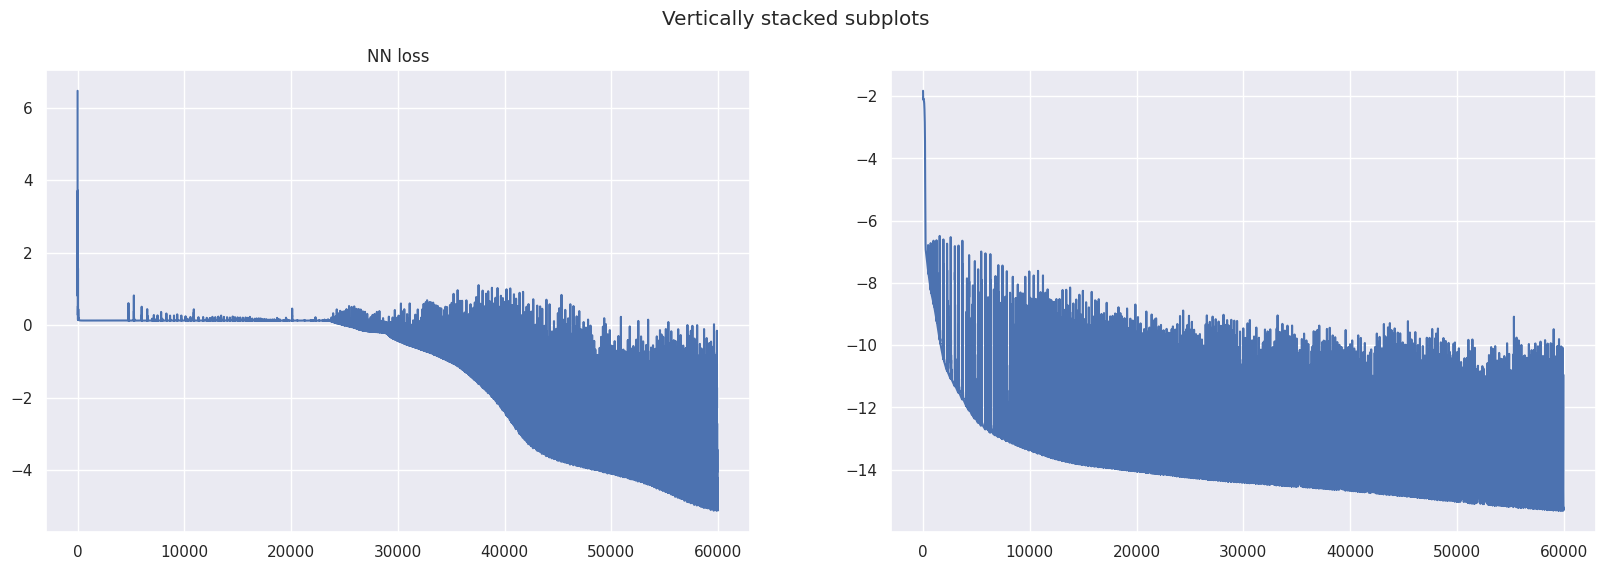

In [20]:
fig, axs = plt.subplots(1,2, figsize=(20,6))
fig.suptitle('Vertically stacked subplots')
axs[0].plot(losses)
axs[1].plot(nn_losses)
axs[0].set_title("PNN loss")
axs[0].set_title("NN loss")
fig.show()

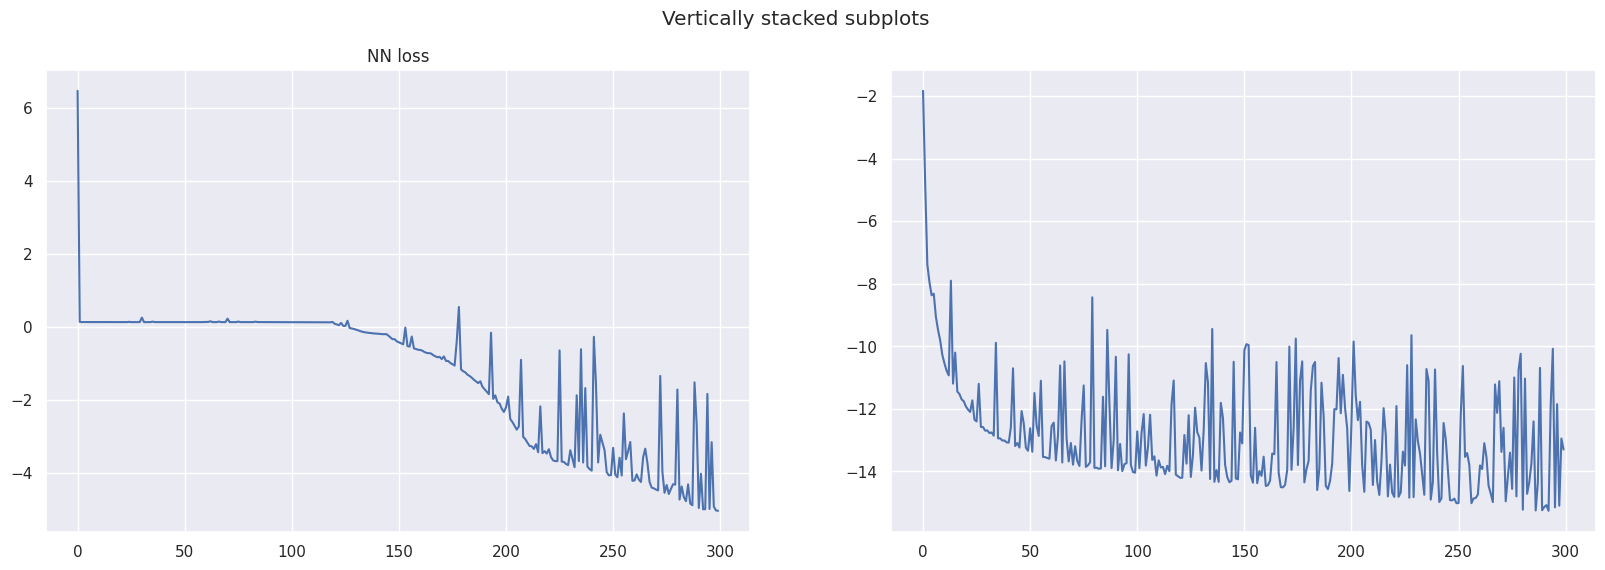

In [21]:
fig, axs = plt.subplots(1,2, figsize=(20,6))
fig.suptitle('Vertically stacked subplots')
axs[0].plot(losses[::200])
axs[1].plot(nn_losses[::200])
axs[0].set_title("PNN loss")
axs[0].set_title("NN loss")
fig.show()

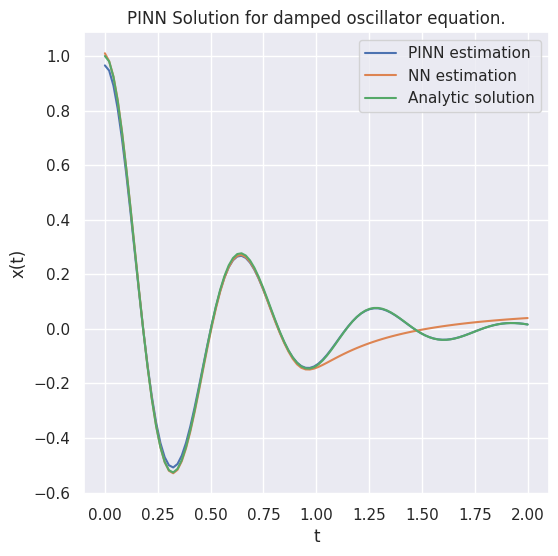

In [22]:
# alias to simplify notation
Z = model.ZETTA
w = model.W

# Test the model
t_test = 2*torch.linspace(0, 1, 100).reshape(-1, 1)
x_test = model(t_test)
x_test_nn = nn_model(t_test)

root = torch.sqrt(torch.tensor([Z**2 - 1], dtype=torch.cfloat))
x_real = x0*torch.exp(-w*Z*t_test)*(torch.cosh(w*root*t_test) + (Z/root)*torch.sinh(w*root*t_test))
x_real = x_real.real

# Plot the results
plt.figure(figsize=(6,6))
plt.plot(t_test.detach().numpy(), x_test.detach().numpy(), label="PINN estimation")
plt.plot(t_test.detach().numpy(), x_test_nn.detach().numpy(), label="NN estimation")
plt.plot(t_test.detach().numpy(), x_real.detach().numpy(), label="Analytic solution")
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('PINN Solution for damped oscillator equation.')
plt.legend()
plt.show()

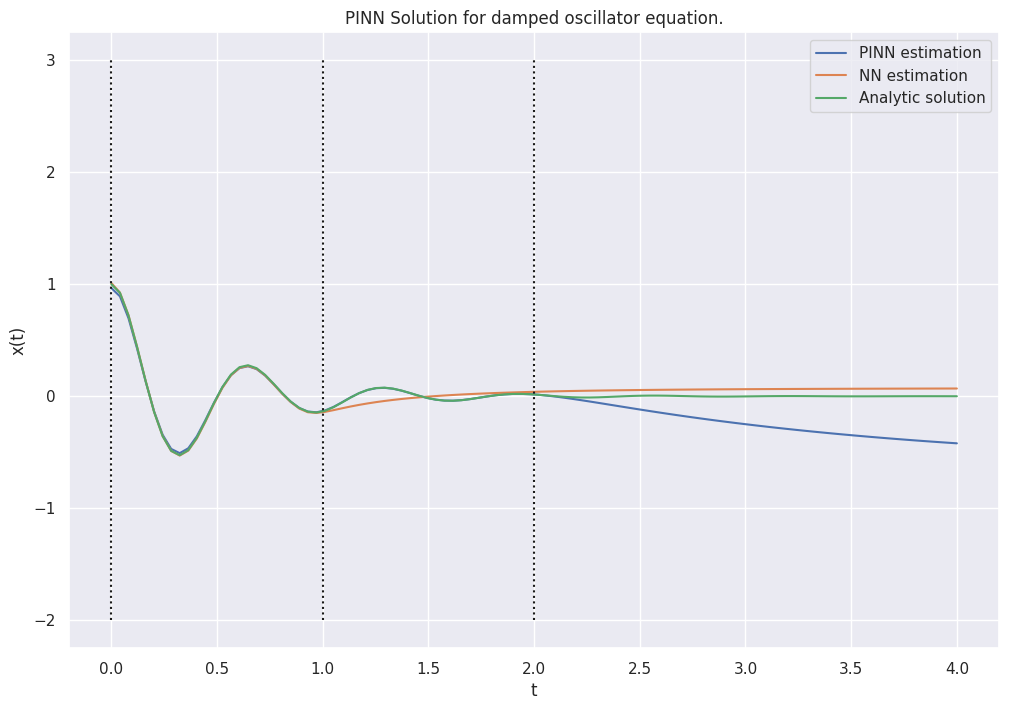

In [34]:
# alias to simplify notation
Z = model.ZETTA
w = model.W

# Test the model
t_test = 2*torch.linspace(0, 2, 100).reshape(-1, 1)
x_test = model(t_test)
x_test_nn = nn_model(t_test)

root = torch.sqrt(torch.tensor([Z**2 - 1], dtype=torch.cfloat))
x_real = x0*torch.exp(-w*Z*t_test)*(torch.cosh(w*root*t_test) + (Z/root)*torch.sinh(w*root*t_test))
x_real = x_real.real

# Plot the results
plt.figure(figsize=(12,8))
plt.plot(t_test.detach().numpy(), x_test.detach().numpy(), label="PINN estimation")
plt.plot(t_test.detach().numpy(), x_test_nn.detach().numpy(), label="NN estimation")
plt.plot(t_test.detach().numpy(), x_real.detach().numpy(), label="Analytic solution")
plt.vlines([0, 1, 2], [-2, -2, -2], [3, 3, 3], colors="k", linestyles="dotted")
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('PINN Solution for damped oscillator equation.')
plt.legend()
plt.show()